In [31]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_s_curve, make_swiss_roll
import torch
import torch.nn as nn
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
import math

In [32]:
from google.colab import drive

drive.mount('/content/drive')

%cd /content/drive/MyDrive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive


In [33]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive


### 1.1 IMS dataset
This time we will adopt the real dataset. The experiment will used the IMS dataset and also the phm2012 dataset.
First we will consider the IMS dataset, specifically the No.2 dataset No. 3 bearing (channel).


The test rig can be seen below:


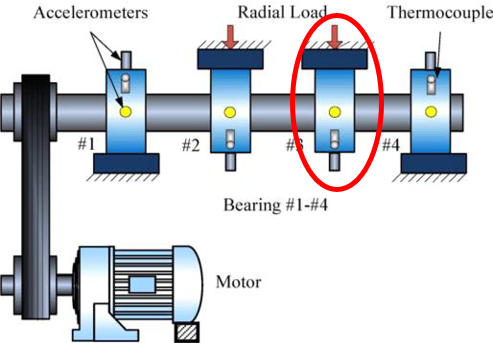



### Training the model using the time-domain data

In [34]:
import scipy.io as scio
from sklearn.model_selection import train_test_split
import pandas as pd
dict_ = scio.loadmat('AE_Diffusion/AE_data_ims/N2_data_C3_.mat')
data_ = dict_['data_c3_']
def normalize(data):
    data_ = (data-np.min(data))/(np.max(data)-np.min(data))
    return data_
#data_h = np.random.randn(1000,4,1024)
data_h = np.random.randn(1000,4,1024)
# data_1 = np.random.randn(4920,4,1024)
data_1 = np.random.randn(4920,4,1024)
ii = 0
for i in range(4920):
  for j in range(4):
    data_1[i,j,:] = normalize(data_[i,1024*j:1024*(j+1)])
    # print(ii)
data_h = data_1[0:1000,:,:]


In [35]:
# data_b = data_1[4000:4920,:,:]
# data_tv = np.concatenate((data_h, data_b),axis = 0)
data_tv = data_h
# data_test  = data_1[1000:-1,:,:]
yh = np.zeros(1000)
# yu = np.ones(920)
# y_ = np.concatenate((yh,yu))
y_ = yh
data_tr,data_va,y_1,y_v = train_test_split(data_tv, y_, test_size=0.2, random_state=42)

batch_size = 64 #考虑到样本总数仅为1000个,batch_size设定为64个
# dataset放到dataloader中
dataset_tensor = torch.utils.data.TensorDataset(torch.tensor(data_tr,dtype=torch.float32).cuda(),torch.tensor(y_1,dtype = torch.float32).cuda())
#dataloader_1 = torch.utils.data.DataLoader(torch.tensor(data_tr,dtype=torch.float32).cuda(), batch_size=batch_size, shuffle=True)
dataloader_1 = torch.utils.data.DataLoader(dataset_tensor,batch_size=batch_size, shuffle=True)



#### model construction

In [36]:
from typing import Callable, Dict, List, Optional, Tuple
from typing import Tuple, Iterator

from typing import Union, Callable, Sequence

import torch

import torch.nn
from torch.nn import Parameter


import torch
import torch.nn as nn
import torch.nn.functional as F

import random
from typing import Tuple, Union

import torch
import tqdm

import abc
from typing import Tuple

import itertools
from typing import Tuple

import torch

from typing import Tuple

import numpy as np
import torch
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

In [37]:
from typing import Union, Tuple

import torch


class AE(torch.nn.Module):
    """
    Simple AE Implementation
    """
    def __init__(self, encoder: torch.nn.Module, decoder: torch.nn.Module, return_latent: bool = False):
        super(AE, self).__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.return_latent = return_latent

    def forward(self, x: torch.Tensor) -> Union[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]]:
        z = self.encoder(x)
        x_pred = self.decoder(z)

        if self.return_latent:
            return x_pred, z

        return x_pred

In [38]:
import abc
from typing import Tuple

import torch
import tqdm


class AnomalyDetector(torch.nn.Module, abc.ABC):
    def __init__(self):
        super(AnomalyDetector, self).__init__()

        # We use this empty parameter to determine the device of the detector
        self.register_buffer('dummy', torch.tensor([]), persistent=False)

    @abc.abstractmethod
    def compute_online_anomaly_score(self, inputs: Tuple[torch.Tensor, ...]) -> torch.Tensor:
        """
        Compute the online anomaly score for a batch of inputs. The output tensor must have the same shape as the
        output of `format_targets` when called with the corresponding targets for this batch. This method expects
        a window (or a batch of windows) as its input and should return a score for the last point in the window.

        :param inputs: tuple of input tensors
        :return: Tensor of shape (B,) that contains the anomaly scores for this batch
        """
        raise NotImplementedError

    @abc.abstractmethod
    def compute_offline_anomaly_score(self, inputs: Tuple[torch.Tensor, ...]) -> torch.Tensor:
        """
        Compute the offline anomaly score for a batch of inputs. The output tensor must have the same shape as the
        output of `format_targets` when called with the corresponding targets for this batch. This method expects
        a window (or a batch of windows) as its input and should return a score for the last point in the window.

        :param inputs: tuple of input tensors
        :return: Tensor of shape (N,) that contains the anomaly scores for this batch
        """
        raise NotImplementedError

    @abc.abstractmethod
    def fit(self, dataset: torch.utils.data.DataLoader) -> None:
        """
        Fit this anomaly detector on a dataset. Note that we assume only normal data here.

        :param dataset: A dataset
        """
        raise NotImplementedError

    @abc.abstractmethod
    def format_online_targets(self, targets: Tuple[torch.Tensor, ...]) -> torch.Tensor:
        """
        Format the labels for a batch of targets. The output tensor must have the same shape as the
        output of `compute_online_anomaly_score` when called with the corresponding inputs for this batch.

        :param targets: tuple of target tensors
        :return: Tensor of shape (B,) that contains the ground truth labels for this batch
        """
        raise NotImplementedError

    def forward(self, inputs: Tuple[torch.Tensor, ...]) -> torch.Tensor:
        return self.compute_online_anomaly_score(inputs)

    def get_labels_and_scores(self, dataset: torch.utils.data.DataLoader) -> Tuple[torch.Tensor, torch.Tensor]:
        # Collect all labels and scores from the dataset
        labels, scores = [], []

        for batch in tqdm.tqdm(dataset):
            batch_inputs, batch_labels = batch
            batch_inputs = tuple(b_in.to(self.dummy.device) for b_in in batch_inputs)

            batch_scores = self.compute_online_anomaly_score(batch_inputs)
            batch_labels = self.format_online_targets(batch_labels)

            labels.append(batch_labels.cpu())
            scores.append(batch_scores.cpu())

        labels = torch.cat(labels, dim=0)
        scores = torch.cat(scores, dim=0)

        assert labels.shape == scores.shape

        return labels, scores


In [39]:
from typing import List, Union, Optional, Tuple, Sequence

import torch
import torch.nn as nn


class RNN(nn.Module):
    def __init__(self, layer_type: str, model: str, input_dimension: int, hidden_dimensions: Union[Sequence[int], int],
                 n_recurrent_layers: Optional[int] = None, recurrent_activation: str = 'tanh',
                 recurrent_bias: bool = True, bidirectional: bool = False, projection_size: int = 0,
                 dilation: Optional[Sequence[int]] = None, dropout: float = 0.0):
        """
        General framework of a recurrent neural network.

        :param layer_type: The type of recurrent layer (RNN, LSTM, GRU).
        :type layer_type: str
        :param model: Type of model (s2s, s2as, s2fh, s2mh)
        :type model: str
        :param input_dimension: Number of dimensions of the feature space of the input data.
        :type input_dimension: int
        :param hidden_dimensions: Number of dimensions of each hidden state for all recurrent layers.
        :type hidden_dimensions: Union[List[int], int]
        :param n_recurrent_layers: Number of recurrent layers, if hidden_dimensions is the same for all layers (int).
        :type n_recurrent_layers: Optional[int]
        :param recurrent_activation: Activation function to use in each recurrent layer (has to be defined in torch.nn).
        :type recurrent_activation: str
        :param recurrent_bias: Whether to use bias in the computations of the recurrent layers.
        :type recurrent_bias: bool
        :param bidirectional: Use bidirectional recurrent layers.
        :type bidirectional: bool
        :param projection_size: Parameter relevant for LSTM layers only. See pytorch docs for details.
        :type projection_size: int
        """

        super(RNN, self).__init__()

        if isinstance(hidden_dimensions, int):
            if n_recurrent_layers is None:
                hidden_dimensions = [hidden_dimensions]
            else:
                hidden_dimensions = [hidden_dimensions for _ in range(n_recurrent_layers)]

        if dilation is None:
            dilation = [0 for _ in hidden_dimensions]
        if len(dilation) != len(hidden_dimensions):
            raise ValueError('Dilation must match the number of hidden layers!')
        self.dilation = dilation

        if layer_type.lower() == 'rnn':
            layer = nn.RNN
        elif layer_type.lower() == 'lstm':
            layer = nn.LSTM
        elif layer_type.lower() == 'gru':
            layer = nn.GRU
        elif callable(layer_type):
            layer = layer_type
        else:
            raise NotImplementedError(layer_type)

        layer_kwargs = {'num_layers': 1, 'bias': recurrent_bias,
                        'batch_first': False,
                        'bidirectional': bidirectional}

        if layer_type.lower() == 'lstm':
            layer_kwargs['proj_size'] = projection_size
        elif layer_type.lower() == 'rnn':
            layer_kwargs['nonlinearity'] = recurrent_activation

        self.dropout = torch.nn.Identity() if dropout <= 0.0 else torch.nn.Dropout(dropout)

        dims = [input_dimension] + list(hidden_dimensions)
        self.recurrent_layers = nn.ModuleList([layer(input_size=input_dim, hidden_size=hidden_dim, **layer_kwargs)
                                               for input_dim, hidden_dim in zip(dims[:-1], dims[1:])])

        self.model = model

    def _base_rnn_forward(self,
                          inputs: Union[torch.Tensor, nn.utils.rnn.PackedSequence],
                          hidden_states: Union[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]] = None,
                          return_all_sequences: bool = False) \
            -> Tuple[Union[List[torch.Tensor], torch.Tensor, nn.utils.rnn.PackedSequence], ...]:
        """
        Apply the base RNN to the sequence and return the hidden states from every step in the sequence.

        :param inputs: Tensor or sequence of shape (T, B, ...)
        :param hidden_states: Hidden states of shape (num_layers, B, ...). For LSTM this must be a tuple of two tensors.
        :param return_all_sequences: Whether the method should return outputs of intermediate layers, too
        :return: If return_all_sequences=False this is a tensor or PackedSequence of shape (T, B, ...),
            otherwise a list of such tensors with one element for each layer is returned.
        """

        # LSTM needs two tensors for hidden state
        if isinstance(hidden_states, tuple):
            hidden_states = zip(*hidden_states)
        elif hidden_states is None:
            hidden_states = (None for _ in self.recurrent_layers)

        layer_output = inputs
        layer_hidden = None
        outputs = []
        hiddens = []

        for i, (layer, dilation, hidden) in enumerate(zip(self.recurrent_layers, self.dilation, hidden_states)):
            if isinstance(hidden, tuple):
                hidden = tuple(torch.unsqueeze(h, dim=0) for h in hidden)
            elif isinstance(hidden, torch.Tensor):
                hidden = torch.unsqueeze(hidden, dim=0)

            if dilation > 1:
                layer_output, layer_hidden = self.apply_dilated_layer(layer, layer_output, dilation, hidden)
            else:
                layer_output, layer_hidden = layer(layer_output, hidden)

            if i < len(self.recurrent_layers) - 1:
                # Apply dropout, but not after the last layer
                layer_output = self.dropout(layer_output)

            if return_all_sequences:
                outputs.append(layer_output)
                hiddens.append(layer_hidden)

        if return_all_sequences:
            return outputs, hiddens

        return layer_output, layer_hidden

    def apply_dilated_layer(self, layer: torch.nn.Module,
                            inputs: Union[torch.Tensor, torch.nn.utils.rnn.PackedSequence], dilation: int,
                            hidden: Union[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]] = None) -> \
            Tuple[Union[torch.Tensor, torch.nn.utils.rnn.PackedSequence],
                  Union[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]]]:
        # TODO: handle packed sequence
        inputs, padding, hidden = self._dilate_inputs(inputs, dilation, hidden)

        outputs, hidden = layer(inputs, hidden)

        outputs = self._restore_outputs(outputs, dilation, padding)

        return outputs, hidden

    @staticmethod
    def _restore_outputs(dilated_outputs: torch.Tensor, dilation: int, input_padding: int) -> torch.Tensor:
        """
        Restores output of a RNN applied to a sequence prepared with _dilate_inputs to its original form.
        That means the subsampled sequences are interleaved again and padding is removed from the end of the sequence.

        :param dilated_outputs: Tensor of shape ((T+padding)//dilation, B*dilation, ...)
        :param dilation: Dilation (subsampling) factor
        :param input_padding: Padding applied to the input sequence before applying the RNN
        :return: Tensor of size (T, B, ...)
        """
        in_shape = dilated_outputs.shape
        batch_size = in_shape[1] // dilation

        blocks = [dilated_outputs[:, i * batch_size: (i + 1) * batch_size] for i in range(dilation)]

        interleaved = torch.stack(blocks).transpose(1, 0).contiguous()
        out_shape = [in_shape[0] * dilation, batch_size] + list(interleaved.shape[3:])
        interleaved = interleaved.view(out_shape)
        if input_padding > 0:
            interleaved = interleaved[:-input_padding]

        return interleaved

    @staticmethod
    def _dilate_inputs(inputs: torch.Tensor, dilation: int, hidden: torch.Tensor = None) -> Tuple[torch.Tensor, int, torch.Tensor]:
        """
        Subsamples the input sequence with a factor of dilation. Each of the first dilation elements is used as
        a starting point for such a subsampled sequence and they are stacked along the batch axis. Note that the
        sequence will be padded with zeros at the end so that its length is a multiple of dilation.

        :param inputs: Tensor of shape (T, B, ...), where T is the sequence length and N the batch size
        :param dilation: Dilation (subsampling) factor
        :param hidden: Tensor of shape (B, hidden_size) containing initial hidden state or a tuple of two such tensors
            in case of the LSTM
        :return: Tensor of shape ((T+padding)//dilation, N*dilation, ...) and the number of time-steps that were
            applied as padding and the new hidden state
        """
        seq_len = inputs.shape[0]
        padding = (seq_len + dilation - 1) // dilation * dilation - seq_len

        if padding > 0:
            pad_shape = [padding] + list(inputs.shape[1:])
            zeros_ = torch.zeros(pad_shape, device=inputs.device, dtype=inputs.dtype)
            inputs = torch.cat((inputs, zeros_))

        dilated_inputs = torch.cat([inputs[j::dilation] for j in range(dilation)], 1)

        if hidden is not None:
            hidden = hidden.repeat(dilation, 1)

        return dilated_inputs, padding, hidden

    def forward(self, inputs: Union[torch.Tensor, nn.utils.rnn.PackedSequence],
                hidden_states: Union[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]] = None,
                return_hidden: bool = False) \
            -> Union[Tuple[torch.Tensor, ...], torch.Tensor, nn.utils.rnn.PackedSequence]:
        """
        Apply the base RNN to the sequence and return the hidden states from every step in the sequence.

        :param inputs: Tensor or sequence of shape (T, B, ...)
        :param hidden_states: Hidden states of shape (num_layers, B, ...). For LSTM this must be a tuple of two tensors.
        :param return_hidden: Whether the method should return hidden states of the RNN too
        :return: If return_hidden=False this is a tensor or PackedSequence of shape (T, B, ...),
            otherwise a Tuple (output, hidden)
        """
        return_all = False
        if self.model == 's2as':
            return_all = True

        output, hidden = self._base_rnn_forward(inputs, hidden_states, return_all_sequences=return_all)

        if self.model in ['s2s', 's2as']:
            pass
        elif self.model == 's2fh':
            output = output[-1]
        elif self.model == 's2mh':
            output = torch.mean(output, dim=0)
        else:
            raise NotImplementedError(f'Model {self.model} is not supported!')

        if return_hidden:
            return output, hidden
        else:
            return output


In [40]:
from typing import Tuple, Iterator

import torch.nn
from torch.nn import Parameter
class BaseModel(torch.nn.Module):
    def grouped_parameters(self) -> Tuple[Iterator[Parameter], ...]:
        return self.parameters(),


In [41]:
import gc
import math
import os
from typing import List, Tuple, Union, Optional

import numpy as np
import pandas as pd
import torch
from torch.nn.utils.rnn import pack_sequence
from torch.optim import Optimizer
from torch.optim.lr_scheduler import StepLR

activations = {
    'relu': torch.nn.ReLU(),
    'sigmoid': torch.nn.Sigmoid(),
    'tanh': torch.nn.Tanh(),
    'linear': torch.nn.Identity()
}


def run_deterministic() -> None:
    # We need to set this environment variable to make CUDA use deterministic algorithms
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    torch.use_deterministic_algorithms(True)
    torch.backends.cudnn.benchmark = False


def run_fast() -> None:
    torch.use_deterministic_algorithms(False)
    torch.backends.cudnn.benchmark = True


def clear_gpu_memory() -> None:
    if torch.cuda.is_available():
        gc.collect()
        torch.cuda.empty_cache()


def set_threads(n : Optional[int] = None) -> None:
    # Set to number of processors
    import torch.multiprocessing as mp
    cpu_count = mp.cpu_count()

    if n is None:
        n = cpu_count

    n = min(n, cpu_count)

    torch.set_num_threads(n)


def collate_fn_variable_length_ts(tensors : List[Tuple[torch.Tensor, torch.Tensor]]) -> Tuple[torch.nn.utils.rnn.PackedSequence, torch.nn.utils.rnn.PackedSequence]:
    return pack_sequence([t[0] for t in tensors], enforce_sorted=False), pack_sequence([t[1] for t in tensors], enforce_sorted=False)


def unpack_sequence(packed_sequence : torch.nn.utils.rnn.PackedSequence) -> List[torch.Tensor]:

    lengths = [0 for _ in range(len(packed_sequence.unsorted_indices))]
    for bs in packed_sequence.batch_sizes:
        for i in range(bs.data.numpy()):
            lengths[i] += 1

    feature_dimension = packed_sequence.data.shape[1:]

    unpacked_sequence = [torch.zeros(l, *feature_dimension) for l in lengths]

    head = 0

    for l_idx, b_size in enumerate(packed_sequence.batch_sizes):
        for b_idx in range(b_size):
            unpacked_sequence[b_idx][l_idx] = packed_sequence.data[head]
            head += 1

    return [unpacked_sequence[idx] for idx in packed_sequence.unsorted_indices]


def generate_random_sequences_like(sequences : Union[torch.Tensor, torch.nn.utils.rnn.PackedSequence]) -> Union[torch.Tensor, torch.nn.utils.rnn.PackedSequence]:

    if isinstance(sequences, torch.nn.utils.rnn.PackedSequence):

        unpacked_sequences = unpack_sequence(sequences)

        z = []
        for sequence in unpacked_sequences:
            z.append(torch.rand(sequence.shape))

        return pack_sequence(z, enforce_sorted=False)

    else:
        return torch.rand(sequences.shape)


def generate_random_sequences(shape : Union[List[Tuple[int, int]], Tuple[int, int]], n : int = 1) -> Union[torch.Tensor, torch.nn.utils.rnn.PackedSequence]:

    if isinstance(shape, tuple):

        assert n > 0
        return torch.rand((n, *shape))

    else:

        sequences = []
        for s in shape:
            sequences.append(torch.rand(s))

        return pack_sequence(sequences, enforce_sorted=False)


def dataset_to_numpy_array(dataset : Union[torch.utils.data.Dataset, torch.utils.data.DataLoader], n : int = -1) -> List[np.array]:
    """
    Accumulates elements from a torch dataset into a numpy array.

    :param dataset: Dataset.
    :type dataset: torch.utils.data.dataset.Dataset or torch.utils.data.DataLoader
    :param n: Maximum number of samples collected from the dataset.
    :type n: int
    :return: Dataset as a list of numpy arrays.
    :rtype: list(numpy.array)
    """

    data_array = None

    if isinstance(dataset, torch.utils.data.DataLoader):

        for i, batch in enumerate(dataset):

            if data_array is None:

                if n > 0:
                    data_array = [batch[idx].detach().numpy()[:n] for idx in range(len(batch))]
                else:
                    data_array = [batch[idx].detach().numpy() for idx in range(len(batch))]

                continue

            if n > 0:
                data_array = [np.append(data_array[idx], batch[idx].detach().numpy()[:n-data_array.shape[0]], axis=0) for idx in range(len(batch))]
            else:
                data_array = [np.append(data_array[idx], batch[idx].detach().numpy(), axis=0) for idx in range(len(batch))]

            if data_array[0].shape[0] == n:
                break

    elif isinstance(dataset, torch.utils.data.Dataset):

        for i, batch in enumerate(dataset):

            if data_array is None:

                data_array = [np.expand_dims(batch[idx].detach().numpy(), axis=0) if isinstance(batch[idx], torch.Tensor) else np.expand_dims(batch[idx], axis=0) for idx in range(len(batch))]

                continue

            data_array = [np.append(data_array[idx], np.expand_dims(batch[idx].detach().numpy(), axis=0), axis=0) if isinstance(batch[idx], torch.Tensor) else np.append(data_array[idx], np.expand_dims(batch[idx], axis=0), axis=0) for idx in range(len(batch))]

            if data_array[0].shape[0] == n:
                break

    else:
        raise AssertionError('Expected Dataset or Dataloader object, but got {}.'.format(type(dataset)))

    return data_array


def sequences_to_dataframe(sequences : Union[torch.Tensor, torch.nn.utils.rnn.PackedSequence]) -> List[pd.DataFrame]:

    if isinstance(sequences, torch.nn.utils.rnn.PackedSequence):

        unpacked_sequences = unpack_sequence(sequences)

        return [pd.DataFrame(sequence.detach().numpy()) for sequence in unpacked_sequences]

    else:

        np_sequences = sequences.detach().numpy()

        return [pd.DataFrame(np_sequences[sequence]) for sequence in range(np_sequences.shape[0])]


def list2tensor(input: Union[List[torch.Tensor], torch.Tensor]) -> torch.Tensor:
    if isinstance(input, torch.Tensor):
        return input

    return torch.stack(input)


def tensor2scalar(tensor: torch.Tensor) -> Union[torch.Tensor, float, int]:
    if tensor.numel() == 1:
        return tensor.item()

    return tensor


def batched_dot(vec1: torch.Tensor, vec2: torch.Tensor) -> torch.Tensor:
    """
    Computes a batched dot product.

    :param vec1: Tensor of shape (\*, D).
    :param vec2: Tensor of shape (\*, D). The batch shapes of both inputs must be broadcastable.
    :return: Tensor of shape (\*)
    """
    return torch.matmul(vec1.unsqueeze(-2), vec2.unsqueeze(-1)).squeeze(-1).squeeze(-1)


def get_device(module: torch.nn.Module) -> torch.device:
    return next(module.parameters()).device


def nested_list2tensor(inputs: List) -> torch.Tensor:
    # Get the dimensions of the final tensor.
    # Note that we assume that all tensors in the nested list have the same shape
    dimensions = []
    oerp = inputs
    while isinstance(oerp, list):
        dimensions.append(len(oerp))
        oerp = oerp[0]
    dimensions.extend(oerp.shape)

    def recursive_update(inp: Union[List, torch.Tensor], res: torch.Tensor):
        if isinstance(inp, list):
            for inp2, res2 in zip(inp, res):
                recursive_update(inp2, res2)
        else:
            res[...] = inp

    result = torch.empty(dimensions, dtype=oerp.dtype, device=oerp.device)
    recursive_update(inputs, result)

    return result


def exponential_moving_avg_(series: torch.Tensor, alpha: float, avg_num: float = 0, avg_denom: float = 0):
    """
    Computes the online adjusted exp weighted average of the errors.
    See https://pandas.pydata.org/docs/user_guide/window.html#window-exponentially-weighted.
    This modifies the given TS tensor in-place.
    """
    one_minus_alpha = 1 - alpha

    for t in range(len(series)):
        avg_num *= one_minus_alpha
        avg_num += series[t]
        avg_denom *= one_minus_alpha
        avg_denom += 1

        series[t] = avg_num / avg_denom

    return avg_num, avg_denom


def unsqueeze_like(to_squeeze : torch.Tensor, like : torch.Tensor, keep_dims : Optional[List] = None) -> torch.Tensor:

    if not keep_dims:
        return to_squeeze[(None,)*(len(like.shape) - len(to_squeeze.shape)) + (...,)]

    target = to_squeeze

    for i, (dim1, dim2) in enumerate(zip([-1] + keep_dims, keep_dims + [len(like.shape)])):
        for expands in range(dim2 - dim1 - 1):
            target = torch.unsqueeze(target, dim1+1)

    return target


def transform_tensor(tensor : Union[Tuple[torch.Tensor], torch.Tensor], current_shape : str, target_shape : str) -> Union[Tuple[torch.Tensor], torch.Tensor]:

    if isinstance(tensor, torch.Tensor):
        return tensor.permute(tuple(current_shape.index(i) for i in target_shape))
    else:
        return tuple(transform_tensor(t, current_shape, target_shape) for t in tensor)


def log1mexp(x: torch.Tensor) -> torch.Tensor:
    """Numerically accurate evaluation of log(1 - exp(x)) for x < 0.
    See [Maechler2012accurate]_ for details.

    .. [Maechler2012accurate] Maechler, Martin (2012). Accurately Computing log(1-exp(-\|a\|)). Assessed from the Rmpfr package.
    """
    mask = -math.log(2) < x
    return torch.where(mask, (-x.expm1()).log(), (-x.exp()).log1p())


class ConstantLR(StepLR):
    def __init__(self, optimizer: Optimizer):
        super().__init__(optimizer, step_size=100, gamma=1)


In [42]:
"""
Collection of general utility functions.
"""
import collections.abc
import functools
import importlib
import inspect
import itertools
import numpy as np
from typing import List, TypeVar, Tuple, Union, Dict, Any, Iterator, Optional



def getitem(x, item):
    return x[item]




In [43]:

import abc
import functools
from typing import Tuple, Union, Callable, List, Type

class LSTMAEDecoder(torch.nn.Module, abc.ABC):
    def __init__(self, enc_hidden_dimension: int, hidden_dimensions: List[int], output_dimension: int):
        super().__init__()

    @abc.abstractmethod
    def forward(self, initial_hidden: torch.Tensor, seq_len: int, x: torch.Tensor = None) -> torch.Tensor:
        raise NotImplementedError


class LSTMAEDecoderSimple(LSTMAEDecoder):
    """
    Reconstruct the time series using a LSTM decoder, starting with an initial hidden state from the encoder
    that is used as input to every timestep of the decoder
    This corresponds to Mirza 2018
    """
    def __init__(self, enc_hidden_dimension: int, hidden_dimensions: List[int], output_dimension: int):
        super().__init__(enc_hidden_dimension, hidden_dimensions, output_dimension)

        self.lstm = RNN(layer_type='LSTM', input_dimension=enc_hidden_dimension, model='s2s',
                        hidden_dimensions=hidden_dimensions + [output_dimension])

    def forward(self, initial_hidden: List[torch.Tensor], seq_len: int, x: torch.Tensor = None) -> torch.Tensor:
        """

        :param initial_hidden: list (length hidden_layers) of tensors of shape (B, D)
        :param seq_len: int that determines the length of the produced sequence
        :param x: The ground truth sequence that should be reconstructed as a tensor of shape (T, B, D).
         This will be fed into the LSTM during training instead of the output from the previous step.
        :return: Tensor of shape (T, B, D)
        """
        # Repeat the encoder output seq_len times
        hidden = torch.unsqueeze(initial_hidden[-1], dim=0)
        h_shape = list(hidden.shape)
        h_shape[0] = seq_len
        hidden = hidden.expand(*h_shape)

        result = self.lstm(hidden)
        return result


class LSTMAEDecoderReverse(LSTMAEDecoder):
    """
    Reconstruct the time series in the opposite direction, starting with an initial hidden state from the encoder
    This corresponds to Malhotra 2016
    """
    def __init__(self, enc_hidden_dimension: int, hidden_dimensions: List[int], output_dimension: int):
        super().__init__(enc_hidden_dimension, hidden_dimensions, output_dimension)

        self.lstm = RNN(layer_type='LSTM', input_dimension=output_dimension, model='s2as',
                        hidden_dimensions=[enc_hidden_dimension] + hidden_dimensions)
        self.linear = torch.nn.Linear(hidden_dimensions[-1], output_dimension)

    def forward(self, initial_hidden: List[torch.Tensor], seq_len: int, x: torch.Tensor = None) -> torch.Tensor:
        """

        :param initial_hidden: tensor of shape (B, D)
        :param seq_len: int that determines the length of the produced sequence
        :param x: The ground truth sequence that should be reconstructed as a tensor of shape (T, B, D).
         This will be fed into the LSTM during training instead of the output from the previous step.
        :return: Tensor of shape (T, B, D)
        """
        # Produce the last output
        hidden = initial_hidden[::-1]
        output = [self.linear(hidden[-1].unsqueeze(0))]
        hidden = (hidden, [torch.zeros_like(h) for h in hidden])

        if self.training and x is not None:
            # Use actual time series input instead of predictions
            # Use only x_2, ..., x_T as inputs, since \hat{x}_1 is predicted from x_2
            # Inputs are reversed, since we want to generate \hat{x}_T, \hat{x}_{T-1}, ..., \hat{x}_1
            inputs = torch.flip(x[1:], dims=(0,))
            result = self.lstm(inputs, hidden_states=hidden)[-1]
            # Apply linear layer
            result = self.linear(result)
            result = torch.cat(output + [result], dim=0)
        else:
            # Generate sequence from scratch
            inputs = output

            for t in range(1, seq_len):
                input = inputs[t-1]
                out, hidden = self.lstm(input, hidden_states=hidden, return_hidden=True)
                output.append(self.linear(out[-1]))
                hidden = [(h.squeeze(0), c.squeeze(0)) for h, c in hidden]

            result = torch.cat(output, dim=0)

        # Reverse output to get the correct order
        result = torch.flip(result, dims=(0,))

        return result


def max_pool(x: torch.Tensor, dim: int = 0) -> torch.Tensor:
    return torch.max(x, dim=dim)[0]


class LSTMAE(AE, BaseModel):
    """
    Generic LSTMAE implementation
    """
    def __init__(self, input_dimension: int, hidden_dimensions=None, latent_pooling: Union[str, Callable] = 'last',
                 decoder_class: Type[LSTMAEDecoder] = LSTMAEDecoderReverse, return_latent: bool = False):
        if hidden_dimensions is None:
            hidden_dimensions = [40]

        encoder = RNN(layer_type='LSTM', input_dimension=input_dimension, model='s2as',
                      hidden_dimensions=hidden_dimensions)
        dec_hidden_dimensions = hidden_dimensions if len(hidden_dimensions) == 1 else hidden_dimensions[-2::-1]
        decoder = decoder_class(enc_hidden_dimension=hidden_dimensions[-1], hidden_dimensions=dec_hidden_dimensions,
                                output_dimension=input_dimension)

        super().__init__(encoder, decoder, return_latent=return_latent)

        if latent_pooling == 'last':
            self.latent_pooling = functools.partial(getitem, item=-1)
        elif latent_pooling == 'mean':
            self.latent_pooling = functools.partial(torch.mean, dim=0)
        elif latent_pooling == 'max':
            self.latent_pooling = functools.partial(max_pool, dim=0)
        elif callable(latent_pooling):
            self.latent_pooling = latent_pooling
        else:
            raise ValueError(f'Pooling method "{latent_pooling}" is not supported!')

    def encode(self, x: torch.Tensor) -> List[torch.Tensor]:
        hidden = self.encoder(x)

        return [self.latent_pooling(h) for h in hidden]

    def forward(self, inputs: Tuple[torch.Tensor]) -> Union[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]]:
        """

        :param inputs: Tuple with a single tensor of shape (T, B, D)
        :return: tensor of shape (T, B, D)
        """
        x, = inputs
        seq_len = x.shape[0]
        hidden = self.encode(x)

        if self.training:
            pred = self.decoder(hidden, seq_len, x)
        else:
            pred = self.decoder(hidden, seq_len)

        if self.return_latent:
            return pred, hidden

        return pred


In [44]:
from typing import Tuple

import numpy as np
import torch
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

class LSTMAEOCSVMAnomalyDetector(AnomalyDetector):
    def __init__(self, model: LSTMAE, kernel: str = 'rbf', gamma: float = 0.001, nu: float = 0.4,
                 normalize_data: bool = False):
        super(LSTMAEOCSVMAnomalyDetector, self).__init__()

        self.model = model
        self.ocsvm = OneClassSVM(kernel=kernel, gamma=gamma, nu=nu)
        if normalize_data:
            self.ocsvm = make_pipeline(StandardScaler(), self.ocsvm)

    def fit(self, dataset: torch.utils.data.DataLoader) -> None:
        latent_vectors = []
        self.model.eval()
        for b_inputs, b_targets in dataset:
            # b_inputs = tuple(b_inp.to(get_device(self.model)) for b_inp in b_inputs)
            x = b_inputs

            with torch.no_grad():
                z = self.model.encode(x)
                latent_vectors.append(z[-1].cpu().numpy())

        latent_vectors = np.concatenate(latent_vectors, axis=0)
        self.ocsvm.fit(latent_vectors)

    def compute_online_anomaly_score(self, inputs: Tuple[torch.Tensor, ...]) -> torch.Tensor:
        x, = inputs
        self.model.eval()
        with torch.no_grad():
            z = self.model.encode(x)

        z = z[-1].cpu().numpy()
        # OCSVM labels normal points as 1 and anomalies as -1, so we have to invert the score
        return -torch.from_numpy(self.ocsvm.score_samples(z))

    def compute_offline_anomaly_score(self, inputs: Tuple[torch.Tensor, ...]) -> torch.Tensor:
        raise NotImplementedError

    def format_online_targets(self, targets: Tuple[torch.Tensor, ...]) -> torch.Tensor:
        # Input of shape (T, B), output of shape (B,)
        target, = targets
        # Just return the last label of the window
        return target[-1]


In [45]:
# model_la = LSTMAE(input_dimension = 4)
# dd = torch.randn((1024,16,4))
# oo = model_la((dd,))

In [46]:
model_la = LSTMAE(input_dimension = 4).cuda()
num_epoch = 100

seed = 3407
torch.cuda.manual_seed(seed)
dataloader = dataloader_1
optimizer_ = torch.optim.Adam(model_la.parameters(),lr = 1e-4)
criterion = nn.MSELoss()
num_epoch = 1000

# epoch遍历
for t in range(num_epoch):
    # dataloader遍历
    model_la.train()
    for idx, (batch_x, batch_y) in enumerate(dataloader):
      batch_x = batch_x.permute(2,0,1)
      predictions= model_la((batch_x,))
      targets = batch_x
      optimizer_.zero_grad()
      loss = criterion(predictions,targets)
      loss.backward()
      optimizer_.step()
    print(
            "[Epoch %d/%d]   [loss %f] "
                % (t,num_epoch, loss.item())
        )

[Epoch 0/1000]   [loss 0.264069] 
[Epoch 1/1000]   [loss 0.249673] 
[Epoch 2/1000]   [loss 0.232603] 
[Epoch 3/1000]   [loss 0.220169] 
[Epoch 4/1000]   [loss 0.211287] 
[Epoch 5/1000]   [loss 0.192592] 
[Epoch 6/1000]   [loss 0.186597] 
[Epoch 7/1000]   [loss 0.163526] 
[Epoch 8/1000]   [loss 0.144086] 
[Epoch 9/1000]   [loss 0.124677] 
[Epoch 10/1000]   [loss 0.102242] 
[Epoch 11/1000]   [loss 0.073416] 
[Epoch 12/1000]   [loss 0.045925] 
[Epoch 13/1000]   [loss 0.032793] 
[Epoch 14/1000]   [loss 0.025555] 
[Epoch 15/1000]   [loss 0.022676] 
[Epoch 16/1000]   [loss 0.019970] 
[Epoch 17/1000]   [loss 0.020114] 
[Epoch 18/1000]   [loss 0.018566] 
[Epoch 19/1000]   [loss 0.018462] 
[Epoch 20/1000]   [loss 0.017844] 
[Epoch 21/1000]   [loss 0.016818] 
[Epoch 22/1000]   [loss 0.017240] 
[Epoch 23/1000]   [loss 0.018328] 
[Epoch 24/1000]   [loss 0.018151] 
[Epoch 25/1000]   [loss 0.018060] 
[Epoch 26/1000]   [loss 0.016906] 
[Epoch 27/1000]   [loss 0.016885] 
[Epoch 28/1000]   [loss 0.0175

In [47]:
model_la.eval()
ano_detector = LSTMAEOCSVMAnomalyDetector(model_la)

In [48]:
# for b_inputs, b_targets in dataset_en:
# # b_inputs = tuple(b_inp.to(get_device(self.model)) for b_inp in b_inputs)
#   print(b_inputs.shape)

In [49]:
data_th = torch.tensor(data_1[0:1000,:,:],dtype = torch.float32).cuda()
data_th = data_th.permute(2,0,1).cuda()
y_h = torch.tensor(np.zeros(1000),dtype = torch.int).cuda()
dataset_en = torch.utils.data.DataLoader((data_th,data_th),batch_size = 16)
ano_detector.fit(dataset_en)

anomaly_scores = torch.ones(4920).cuda()
with torch.no_grad():
  data_tv = torch.tensor(data_1,dtype = torch.float32).cuda()
  data_tv = data_tv.permute(2,0,1)
  for i in range(984):
    anomaly_scores[5*i:5*(i+1)] = ano_detector.compute_online_anomaly_score((data_tv[:,5*i:5*(i+1),:],))


In [50]:
HI_m_ = anomaly_scores.detach().cpu().numpy()
HI_m = np.ones(984)
for i in range(984):
  HI_m[i] = np.mean(HI_m_[5*i:5*(i+1)])


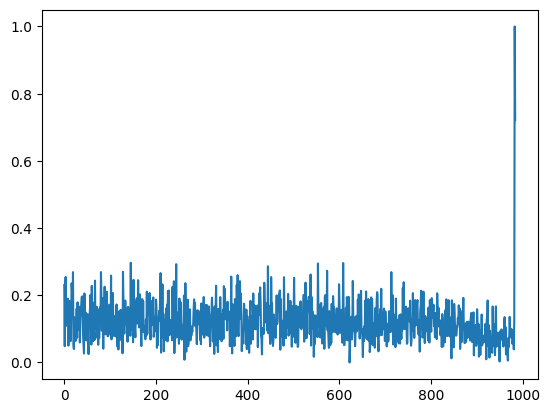

In [51]:
HI_m = normalize(HI_m)
plt.plot(HI_m)

In [52]:
import scipy.io as scio
HI_t = HI_m
HI_t_ = HI_m_
scio.savemat('AE_Diffusion/AE_data_ims/result_1000_IMS_lstmae_ocsvm(2).mat',{'HI_t':HI_t,'HI_t_':HI_t_})

#### Trying to train the model

In [ ]:
num_epoch = 1000

dataloader = dataloader_1


# epoch遍历
for t in range(num_epoch):
    # dataloader遍历
    model_t.train()
    for idx, (batch_x, batch_y) in enumerate(dataloader):
        loss_1,loss_2,loss_recon_ = Trainer_lstem_vae_gan.train_batch(model_,(AnomTransf_Loss(lamb=3.0),),(torch.optim.Adam(model_.parameters(),lr = 0.0001),),1000,1000,(batch_x,),(batch_x,))
        print(
            "[Epoch %d/%d]   [loss_1 %f] [loss_2: %f] [loss_recon_: %f]"
                % (t,num_epoch, loss_1, loss_2, loss_recon_)
        )



RuntimeError: one of the variables needed for gradient computation has been modified by an inplace operation: [torch.cuda.FloatTensor [64, 20, 1024]], which is output 0 of ReluBackward0, is at version 4; expected version 0 instead. Hint: enable anomaly detection to find the operation that failed to compute its gradient, with torch.autograd.set_detect_anomaly(True).

#### anomaly detector

In [ ]:
def compute_online_anomaly_score(
    model, inputs: Tuple[torch.Tensor, ...]
) -> torch.Tensor:
    # Input of shape [B, T, F] output of shape (B,)
    (x,) = inputs

    # Temperatur from online implementation
    temperature = 50.
    model.eval()
    with torch.no_grad():
        output, series, priors, _ = model(x)
        # Calc recon loss with mean over features: out shape [B, T]
        recon_loss = F.mse_loss(x, output, reduction='none').mean(dim=-1)

        # Init losses
        series_loss = 0.0
        prior_loss = 0.0
        for serie, prior in zip(series,priors):
            prior_norm = prior.div(torch.sum(prior, dim=-1, keepdim=True))
            series_loss += symm_kl_loss(serie, prior_norm, reduce=False) * temperature

        metric = torch.softmax((-series_loss - prior_loss), dim=-1)
        anomaly_scores = metric * recon_loss

    # Return last observations
    return anomaly_scores[:,-1]
data_tv = torch.tensor(data_1,dtype = torch.float32).cuda()
anomaly_score_ = compute_online_anomaly_score(model_t, (data_tv,))



In [ ]:
HI_m_ = anomaly_score_.cpu().numpy()
HI_m = np.ones(984)
for i in range(984):
  HI_m[i] = np.mean(HI_m_[5*i:5*(i+1)])


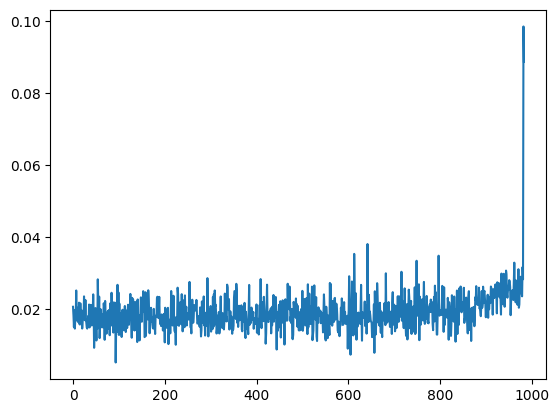

In [ ]:
plt.plot(HI_m)

In [ ]:
import scipy.io as scio
HI_t = HI_m
HI_t_ = HI_m_
scio.savemat('AE_Diffusion/AE_data_ims/result_1000_IMS_anomaly_transformer.mat',{'HI_t':HI_t,'HI_t_':HI_t_})

In [ ]:
def compute_online_anomaly_score(
    self, inputs: Tuple[torch.Tensor, ...]
) -> torch.Tensor:
    # Input of shape [B, T, F] output of shape (B,)
    (x,) = inputs

    # Temperatur from online implementation
    temperature = 50.

    with torch.no_grad():
        output, series, priors, _ = self.model(x)
        # Calc recon loss with mean over features: out shape [B, T]
        recon_loss = F.mse_loss(x, output, reduction='none').mean(dim=-1)

        # Init losses
        series_loss = 0.0
        prior_loss = 0.0
        for serie, prior in zip(series,priors):
            prior_norm = prior.div(torch.sum(prior, dim=-1, keepdim=True))
            series_loss += symm_kl_loss(serie, prior_norm, reduce=False) * temperature

        metric = torch.softmax((-series_loss - prior_loss), dim=-1)
        anomaly_scores = metric * recon_loss

    # Return last observations
    return anomaly_scores[:,-1]

TypeError: AnomTransf_Trainer.train_batch() missing 7 required positional arguments: 'network', 'losses', 'optimizers', 'epoch', 'num_epochs', 'b_inputs', and 'b_targets'

In [ ]:

wdt_discriminator=WDT_discriminator().cuda()
wdt_generator=WDT_generator().cuda()
optimizer_g = torch.optim.Adam(wdt_generator.parameters(),lr=5e-5)
optimizer_d = torch.optim.Adam(wdt_discriminator.parameters(),lr=5e-5)

In [ ]:
#针对Pytorch的数据归一化
def normalize_t(data):
    return (data-torch.min(data))/(torch.max(data)-torch.min(data))
data_test= data_vali.view(-1,1,4096)
num_test = 4920
wdt_discriminator.eval()
HI_m_ = wdt_discriminator(data_test)

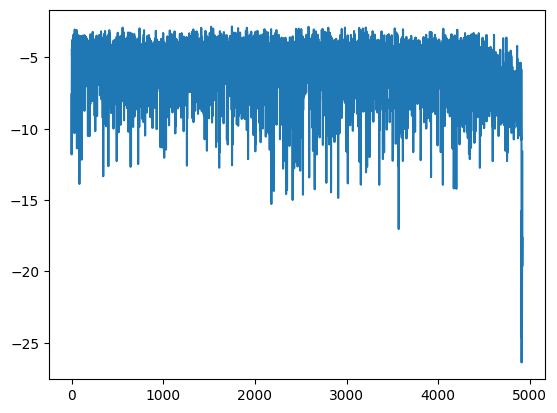

In [ ]:
import matplotlib.pyplot as plt

HI_m = HI_m_.detach().cpu().numpy().reshape(-1)
plt.plot(HI_m)

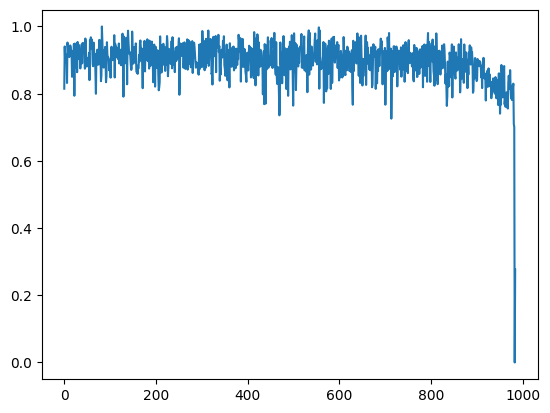

In [ ]:
#针对numpy数组的标准化
def normalize_np(data):
    return (data-np.min(data))/(np.max(data)-np.min(data))
HI_t_ = np.ones(984)
HI_t = np.ones(984)
for i in range(984):
  HI_t_[i] = np.mean(HI_m[5*i:(i+1)*5])

HI_t = normalize_np(HI_t_)
plt.plot(HI_t)

In [ ]:
import scipy.io as scio
scio.savemat('AE_Diffusion/AE_data_ims/result_1000_IMS_WGAN-GP.mat',{'HI_t':HI_t,'HI_t_':HI_t_})